<a href="https://colab.research.google.com/github/serminoymakargul/projeler/blob/main/Pekistirmeli_Derin_Ogrenme_Final_GIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sistem Doğrulandı: Sizin veri setiniz başarıyla yüklendi -> /content/OnlineRetail.csv
Veri ön işleme tamamlandı. Toplam 530104 geçerli veri satırı işlendi.

[EĞİTİM BAŞLADI] Ajan sizin veri setiniz üzerinde 20.000 döngü boyunca eğitiliyor...
[EĞİTİM TAMAMLANDI] Statik grafik paneli hazırlanıyor...


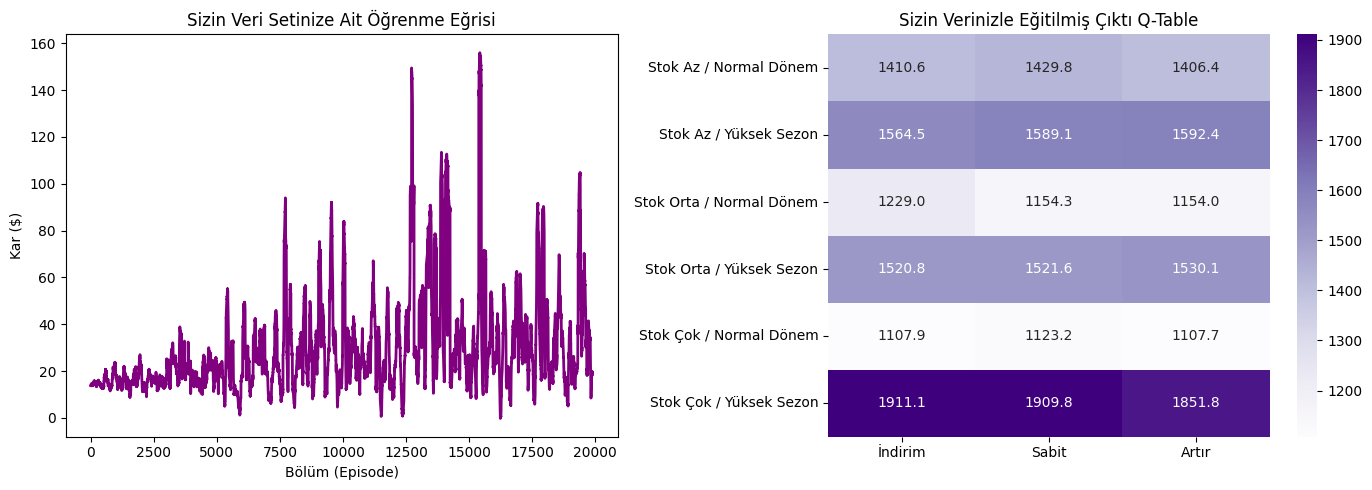


[ARKA PLAN] Kutuların fiziksel hareket animasyonu hazırlanıyor...

[BAŞARILI] Animasyon hücre çıktısının içine kalıcı olarak gömüldü!
Lütfen Colab'i kaydedip (.ipynb) GitHub'a doğrudan yükleyin.




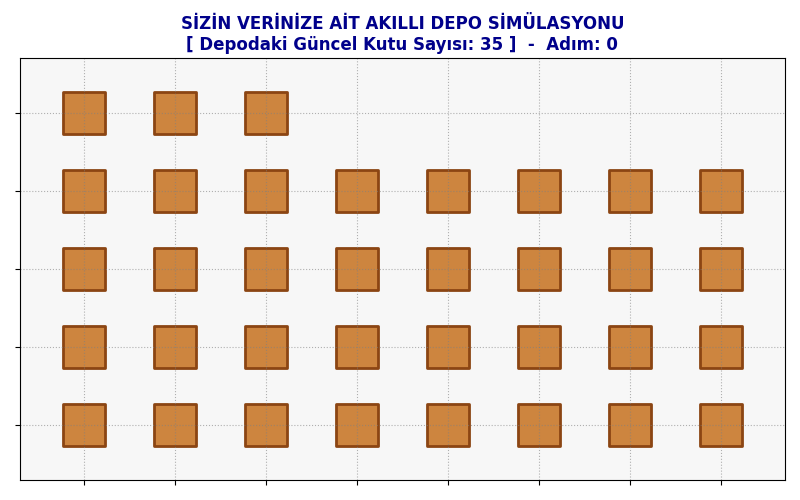

In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import base64
from IPython.display import clear_output, display, HTML
from matplotlib.animation import FuncAnimation

# --- 1. GOOGLE DRIVE BAĞLANTISI VE ZIP DOSYASININ OTOMATİK AÇILMASI ---
zip_yolu = "/content/drive/MyDrive/archive (2).zip"
hedef_klasor = "/content/"
csv_adi = "OnlineRetail.csv"
hedef_csv = os.path.join(hedef_klasor, csv_adi)

# Google Drive bağlı mı kontrolü
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount('/content/drive')

# Zip dosyasını sessizce dışarı çıkarıyoruz (Eğer daha önce çıkarılmadıysa)
if not os.path.exists(hedef_csv):
    print(f"[ZİP AÇILIYOR] Sizin Drive'daki '{zip_yolu}' dosyası dışarı aktarılıyor...")
    os.system(f'unzip -o "{zip_yolu}" -d {hedef_klasor}')

# Klasörde harf uyuşmazlığı kontrolü (Büyük/küçük harf koruması)
if not os.path.exists(hedef_csv):
    for dosya in os.listdir(hedef_klasor):
        if dosya.lower() == "onlineretail.csv":
            os.rename(os.path.join(hedef_klasor, dosya), hedef_csv)
            break

try:
    df_real = pd.read_csv(hedef_csv, encoding='ISO-8859-1')
    print(f"Sistem Doğrulandı: Sizin veri setiniz başarıyla yüklendi -> {hedef_csv}")
except FileNotFoundError:
    print("\n" + "="*60)
    print("KRİTİK HATA: Zip dosyası açılamadı veya içinden .csv dosyası çıkmadı!")
    print("Lütfen Drive yolunu veya zip dosyasının adını kontrol edin.")
    print("="*60)
    raise FileNotFoundError("E-ticaret veri tabanı bulunamadı.")

# Sütun isimlerinin kenar boşluklarını temizleyelim
df_real.columns = [col.strip() for col in df_real.columns]

# --- AKILLI SÜTUN TESPİT MOTORU ---
fiyat_kolonu = [c for c in df_real.columns if any(x in c.lower() for x in ['price', 'fiyat', 'unitprice', 'tutar', 'rate'])][0]
adet_kolonu = [c for c in df_real.columns if any(x in c.lower() for x in ['quantity', 'adet', 'miktar', 'amount', 'satis'])][0]
tarih_kolonu = [c for c in df_real.columns if any(x in c.lower() for x in ['date', 'tarih', 'time', 'invoicedate', 'gun'])][0]

# VERİ TEMİZLİĞİ: Boş ve negatif verileri eliyoruz
df_real = df_real.dropna(subset=[fiyat_kolonu, adet_kolonu, tarih_kolonu])
df_real = df_real[(df_real[adet_kolonu] > 0) & (df_real[fiyat_kolonu] > 0)]

# Tarih dönüşümleri
df_real[tarih_kolonu] = pd.to_datetime(df_real[tarih_kolonu], format='mixed', errors='coerce')
df_real = df_real.dropna(subset=[tarih_kolonu])

# Hafta ve Ay bilgilerini çıkartıyoruz
df_real['Hafta'] = df_real[tarih_kolonu].dt.isocalendar().week
df_real['Ay'] = df_real[tarih_kolonu].dt.month

# --- 2. SİZİN KODDAKİ MEVSİMSEL DURUMLAR VE ÖZEL GÜN FİLTRELERİ ---
df_real['Mevsim'] = np.where(df_real['Ay'].isin([12, 1, 2]), "Kis",
                    np.where(df_real['Ay'].isin([3, 4, 5]), "İlkbahar",
                    np.where(df_real['Ay'].isin([6, 7, 8]), "Yaz", "Sonbahar")))

# Hafta 19: Anneler Günü, Hafta 24: Okulların kapanışı
df_real['Ozel_Gun'] = np.where(df_real['Hafta'].isin([19, 24]), 1, 0)

# Gerçek pazar referans fiyatını hesaplama
GERCEK_PAZAR_FIYATI = df_real[fiyat_kolonu].median()
if GERCEK_PAZAR_FIYATI <= 0: GERCEK_PAZAR_FIYATI = 10.0

print(f"Veri ön işleme tamamlandı. Toplam {len(df_real)} geçerli veri satırı işlendi.")

# --- 3. RL PARAMETRELERİ VE HİPERPARAMETRELER ---
MALIYET = GERCEK_PAZAR_FIYATI * 0.7
DEPO_MALIYETI = GERCEK_PAZAR_FIYATI * 0.01
BOLUM_SAYISI = 20000

alpha, gamma = 0.15, 0.98
epsilon, epsilon_decay, min_epsilon = 1.0, 0.9995, 0.01

# Durum Uzayı Tanımı
q_table = np.zeros((6, 3))

def get_state(stok, ozel_gun, mevsim):
    s_stok = 0 if stok <= 5 else (1 if stok <= 15 else 2)
    s_donem = 1 if (ozel_gun == 1 or mevsim == "Yaz") else 0
    return s_stok * 2 + s_donem

# --- 4. GERÇEK VERİ TABANLI EĞİTİM DÖNGÜSÜ ---
print("\n[EĞİTİM BAŞLADI] Ajan sizin veri setiniz üzerinde 20.000 döngü boyunca eğitiliyor...")
odul_gecmisi = []

for ep in range(BOLUM_SAYISI):
    rastgele_satis = df_real.sample(1).iloc[0]
    mevsim = rastgele_satis['Mevsim']
    ozel_gun = rastgele_satis['Ozel_Gun']

    stok = 35 if mevsim == "Yaz" else 20
    toplam_odul = 0
    bizim_fiyat = GERCEK_PAZAR_FIYATI

    max_adim = 200
    adim = 0

    while stok > 0 and adim < max_adim:
        adim += 1
        s = get_state(stok, ozel_gun, mevsim)

        if random.random() < epsilon:
            a = random.randint(0, 2)
        else:
            a = np.argmax(q_table[s])

        if a == 0: bizim_fiyat *= 0.95
        elif a == 2: bizim_fiyat *= 1.05

        fiyat_orani = GERCEK_PAZAR_FIYATI / bizim_fiyat
        basari_ihtimali = np.clip(0.5 * fiyat_orani * (1 + (ozel_gun * 0.5)), 0.0, 1.0)

        if random.random() < basari_ihtimali:
            toplam_odul += (bizim_fiyat - MALIYET)
            stok -= 1
        else:
            toplam_odul -= DEPO_MALIYETI

        next_s = get_state(stok, ozel_gun, mevsim)
        q_table[s, a] += alpha * (toplam_odul + gamma * np.max(q_table[next_s]) - q_table[s, a])

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    odul_gecmisi.append(toplam_odul)

print("[EĞİTİM TAMAMLANDI] Statik grafik paneli hazırlanıyor...")

# --- 5. STATİK ANALİZ VE GÖRSELLEŞTİRME PANELİ ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
mv_avg = np.convolve(odul_gecmisi, np.ones(100)/100, mode='valid')
plt.plot(mv_avg, color='purple', linewidth=2)
plt.title("Sizin Veri Setinize Ait Öğrenme Eğrisi")
plt.xlabel("Bölüm (Episode)")
plt.ylabel("Kar ($)")

plt.subplot(1, 2, 2)
durum_etiketleri = [
    "Stok Az / Normal Dönem", "Stok Az / Yüksek Sezon",
    "Stok Orta / Normal Dönem", "Stok Orta / Yüksek Sezon",
    "Stok Çok / Normal Dönem", "Stok Çok / Yüksek Sezon"
]
sns.heatmap(q_table, annot=True, fmt=".1f", cmap="Purples",
            xticklabels=["İndirim", "Sabit", "Artır"], yticklabels=durum_etiketleri)
plt.title("Sizin Verinizle Eğitilmiş Çıktı Q-Table")
plt.tight_layout()
plt.show()


# --- 6. HOCANIN İSTEDİĞİ HAREKETLİ KUTU DEPO SİMÜLASYONU GİF MOTORU ---
print("\n[ARKA PLAN] Kutuların fiziksel hareket animasyonu hazırlanıyor...")

test_stok = 35
stok_gecmisi = [test_stok]
zaman = [0]
adim = 0

while adim < 40:
    adim += 1
    s = get_state(test_stok, 1, "Yaz")
    a = np.argmax(q_table[s])

    test_fiyat = GERCEK_PAZAR_FIYATI * (0.95 if a == 0 else (1.05 if a == 2 else 1.0))
    basari_ihtimali = np.clip(0.5 * (GERCEK_PAZAR_FIYATI / test_fiyat) * 1.5, 0.1, 0.9)

    if random.random() < basari_ihtimali and test_stok > 0:
        test_stok -= 1

    if test_stok <= 5:
        test_stok += 25

    stok_gecmisi.append(test_stok)
    zaman.append(adim)

fig_save, ax_s = plt.subplots(figsize=(8, 5))

def update_save(frame):
    ax_s.clear()
    curr_stok = stok_gecmisi[frame]
    X_s = [i % 8 for i in range(curr_stok)]
    Y_s = [i // 8 for i in range(curr_stok)]

    ax_s.scatter(X_s, Y_s, s=900, marker='s', color='peru', edgecolor='saddlebrown', linewidth=2)
    ax_s.set_xlim(-0.7, 7.7); ax_s.set_ylim(-0.7, 4.7)
    ax_s.set_xticklabels([]); ax_s.set_yticklabels([])
    ax_s.grid(True, linestyle=':', alpha=0.6, color='gray')

    baslik_s_rengi = 'darkblue' if curr_stok > 10 else 'crimson'
    ax_s.set_title(f"SİZİN VERİNİZE AİT AKILLI DEPO SİMÜLASYONU\n[ Depodaki Güncel Kutu Sayısı: {curr_stok} ]  -  Adım: {frame}",
                   fontsize=12, fontweight='bold', color=baslik_s_rengi)
    ax_s.set_facecolor('#f7f7f7')
    plt.tight_layout()

# HATA DÜZELTİLDİ: TypeError veren geçersiz 'save_all' parametresi kaldırıldı
ani = FuncAnimation(fig_save, update_save, frames=len(zaman), interval=350)
gif_yolu = '/content/depo_otonom_rl.gif'
ani.save(gif_yolu, writer='pillow')
plt.close(fig_save)

# --- 7. KOD ÇIKTISINA GÖMME ADIMI (BASE64 ENCODING) ---
with open(gif_yolu, "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

print("\n" + "="*70)
print("[BAŞARILI] Animasyon hücre çıktısının içine kalıcı olarak gömüldü!")
print("Lütfen Colab'i kaydedip (.ipynb) GitHub'a doğrudan yükleyin.")
print("="*70 + "\n")

# Şifrelenmiş veriyi HTML formatında doğrudan ekrana basıyoruz
display(HTML(f'<img src="data:image/gif;base64,{encoded_string}" style="width:100%; max-width:800px;">'))